# 15 - accDM daughter: fluid-closure diagnostic + plateau ceff2 closure

1. **Diagnostic (Tasks 1-5):** pole-masked raw `delta_p/delta_rho`, `sigma/delta` vs `x=k/k_fs`. Universal at `x<1`, envelope splits by **eta (not f)** at `x>1` -> `f<=0.3` is not the obstacle.
2. **Fit (Task 6):** the binned **median** `ceff2` is a flat plateau `c_fs` over the bulk, rising back to `ca2 -> ~1` at very high `x` (relativistic birth, earliest times). Closure: `ceff2(a) = min(max(ca2(a), c_fs), 1/3)`. Measured plateau (kappa=6, a_t=0.13): `c_fs = {0.1: 0.030, 0.3: 0.095, 1.0: 0.228}` - all sub-1/3, monotone in eta (published `W=1-2*eps_acc` has the **wrong sign**, `memory: ceff2-fit-structure`).
3. **Task 7 (kappa/a_t sweep, done):** `c_fs` spread = **50% across kappa {2,6,20}**, **170% across a_t {0.01,0.13,0.5}** -> `c_fs(eta)` alone is dead. But the pattern (later birth / broader turn-on -> warmer today -> larger c_fs) says `c_fs` is the **frozen late-time dispersion**.
4. **Task 8 (decisive):** is `c_fs = A * ca2_bg(a=1)` with one universal `A` across all (eta, f, kappa, a_t)? If yes, Phase 2 is parameter-free - all model knobs enter via the background.

`w_sigma`/`w_theta` are zero in the exact hierarchy (`memory: w-sigma-zero-in-exact-hierarchy`). Extractions are **pickle-cached** under `accDM_scans/nb15_cache/` - re-runs are cheap after the first pass. Phase 3 (post-rebuild): P(k) over **k<=1 only**.

In [1]:
import sys, os, pickle; sys.path.insert(0, '.')   # import helpers from notebooks_test/
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class
from fluid_closure_helpers import (
    ca2_from_kfs, mask_small_denom, log_upper_envelope, collapse_band, ceff2_f_eta,
)

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628', '#999999', '#e41a1c', '#dede00']

# --- base cosmology + accDM model (same setup as notebook 7) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

A_T, MASS, KAPPA = 0.13, 1e16, 6.0
A_REC = 1.0 / (1.0 + 1090.0)

# --- diagnostic sweep grids ---
K_GRID   = np.logspace(-2, 0.0, 18)          # 1/Mpc: sub-horizon, spans below to above k_fs
F_LIST   = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]             # daughter fraction up to the target
ETA_LIST = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]                    # 3 boosts -> pin c_fs(eta)
DROP_FRAC = 0.01                               # pole mask: drop smallest 20% of |denominator|

# --- extraction cache (bump CACHE_TAG when the extractor or params change) ---
CACHE_DIR = os.path.join('accDM_scans', 'nb15_cache'); os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_TAG = 'v6'

def eps_acc_of_eta(eta):
    e2 = eta*eta
    return -e2 + np.sqrt(e2*e2 + 4*e2*eta + 5*e2 + 2*eta) - 2*eta

def accdm_params(eta, f_acc=0.1, kappa=KAPPA, a_t=A_T):
    """Exact-hierarchy accDM params for a given boost eta, fraction f_acc, and (kappa, a_t)."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 1001', 'N_ur': 0.00441,
              'background_Nloga': 5001, 'gauge': 'synchronous',
              'get_perturbations_in_current_gauge': 'yes',
              'ncdm_fluid_trigger_tau_over_tau_k': 25,
              'ncdm_fluid_approximation': 3})          # 3 = none (exact hierarchy)
    return p

print('setup OK; W(eta):', {e: round(1 - 2*eps_acc_of_eta(e), 3) for e in ETA_LIST},
      '<- decreases with eta (data increases -> W wrong sign)')

setup OK; W(eta): {0.01: np.float64(0.754), 0.05: np.float64(0.533), 0.1: np.float64(0.412), 0.3: np.float64(0.22), 0.5: np.float64(0.146), 1.0: np.float64(0.072)} <- decreases with eta (data increases -> W wrong sign)


## Task 2 - tau-series extractor (+ disk cache)

In [2]:
def _find_key(d, want):
    if want in d:
        return want
    for kk in d:
        if kk.replace(' ', '').startswith(want.replace(' ', '')):
            return kk
    raise KeyError('{!r} not found; available: {}'.format(want, list(d.keys())))

def extract_daughter_series(params, k_list):
    """Run exact CLASS; return {k: dict of daughter tau-series arrays}."""
    ks = np.sort(np.asarray(k_list, float))
    p = dict(params); p['k_output_values'] = ', '.join('{:.8e}'.format(k) for k in ks)
    M = Class(); M.set(p); M.compute()
    perts = M.get_perturbations()['scalar']
    bg = M.get_background()
    tau_bg = np.asarray(bg['conf. time [Mpc]'], float)
    a_bg   = 1.0 / (1.0 + np.asarray(bg['z'], float))
    H_bg   = np.asarray(bg['H [1/Mpc]'], float)
    o = np.argsort(tau_bg); tau_bg, a_bg, H_bg = tau_bg[o], a_bg[o], H_bg[o]
    kd  = _find_key(perts[0], 'delta_ncdm[1]'); kt  = _find_key(perts[0], 'theta_ncdm[1]')
    ksh = _find_key(perts[0], 'shear_ncdm[1]'); kc  = _find_key(perts[0], 'cs2_ncdm[1]')
    kf  = _find_key(perts[0], 'k_fss_acc[1]');  ktau = _find_key(perts[0], 'tau')
    out = {}
    for k, d in zip(ks, perts):
        tau = np.asarray(d[ktau], float)
        a   = np.interp(tau, tau_bg, a_bg)
        aH  = a * np.interp(tau, tau_bg, H_bg)
        out[k] = dict(tau=tau, a=a, aH=aH,
                      delta=np.asarray(d[kd], float), theta=np.asarray(d[kt], float),
                      shear=np.asarray(d[ksh], float), dpr=np.asarray(d[kc], float),
                      k_fs=np.asarray(d[kf], float))
    M.struct_cleanup(); M.empty()
    return out

def cached_extract(eta, f_acc, kappa=KAPPA, a_t=A_T):
    """Disk-cached extraction: one exact CLASS run per unique config, then pickle."""
    key = '{}_eta{:g}_f{:g}_kap{:g}_at{:g}_nk{}'.format(CACHE_TAG, eta, f_acc, kappa, a_t, K_GRID.size)
    path = os.path.join(CACHE_DIR, key + '.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as fh:
            return pickle.load(fh)
    ser = extract_daughter_series(accdm_params(eta, f_acc=f_acc, kappa=kappa, a_t=a_t), K_GRID)
    with open(path, 'wb') as fh:
        pickle.dump(ser, fh)
    return ser

In [3]:
_probe = cached_extract(ETA_LIST[0], 0.1)
_s = _probe[K_GRID[0]]
for q in ('theta', 'shear', 'dpr', 'k_fs', 'aH', 'a', 'tau'):
    assert _s[q].shape == _s['delta'].shape, q
g = (_s['k_fs'] > 0) & np.isfinite(_s['aH'])
ca2 = ca2_from_kfs(_s['k_fs'][g], _s['aH'][g])
print('extractor OK; tau samples per k =', _s['delta'].size,
      '| ca2 in [{:.2e},{:.2e}] | x=k/k_fs reaches {:.0f}'.format(
          ca2.min(), ca2.max(), (K_GRID.max()/_s['k_fs'][g]).max()))
assert np.all(ca2 <= 1.0 + 1e-6), 'ca2 > 1 -> aH/k_fs mismatch (check background keys)'

extractor OK; tau samples per k = 352 | ca2 in [2.20e-04,2.03e-02] | x=k/k_fs reaches 334


## Task 3 - run the sweep once (cached), build response envelopes

In [4]:
def responses_from_series(ser, eta, drop_frac=DROP_FRAC):
    W = 1/(1+eta) #1 - 2*eps_acc_of_eta(eta)
    Xc, Ce, Cf, Sd, Xv, Rv = [], [], [], [], [], []
    for k, s in ser.items():
        g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
        if not np.any(g):
            continue
        x   = k / s['k_fs'][g]
        ca2 = ca2_from_kfs(s['k_fs'][g], s['aH'][g])
        delta = s['delta'][g]; theta = s['theta'][g]
        shear = s['shear'][g]; dpr = s['dpr'][g]
        safe_d = np.where(delta == 0, np.nan, delta)
        safe_t = np.where(theta == 0, np.nan, theta)
        Xc.append(x); Ce.append(np.abs(mask_small_denom(dpr, delta, drop_frac)))
        Cf.append(ca2 * (1 + 0.2*W*np.sqrt(x)))
        Sd.append(np.abs(mask_small_denom(shear/safe_d, delta, drop_frac)))
        Xv.append(x); Rv.append(np.abs(mask_small_denom(k*shear/safe_t, theta, drop_frac)))
    cat = np.concatenate
    return {'ceff2':   log_upper_envelope(cat(Xc), cat(Ce)),
            'ceff2_fit': log_upper_envelope(cat(Xc), cat(Cf)),
            'sig_del': log_upper_envelope(cat(Xc), cat(Sd)),
            'Rv':      log_upper_envelope(cat(Xv), cat(Rv))}

SERIES, RESPONSES = {}, {}
for eta in ETA_LIST:
    for f in tqdm(F_LIST, desc='eta={}'.format(eta)):
        ser = cached_extract(eta, f)
        SERIES[(f, eta)] = ser
        RESPONSES[(f, eta)] = responses_from_series(ser, eta)
print('cached', len(SERIES), 'series / responses')

eta=1.0: 100%|██████████| 6/6 [00:00<00:00, 11.31it/s]

cached 36 series / responses


## Task 4 - collapse plots

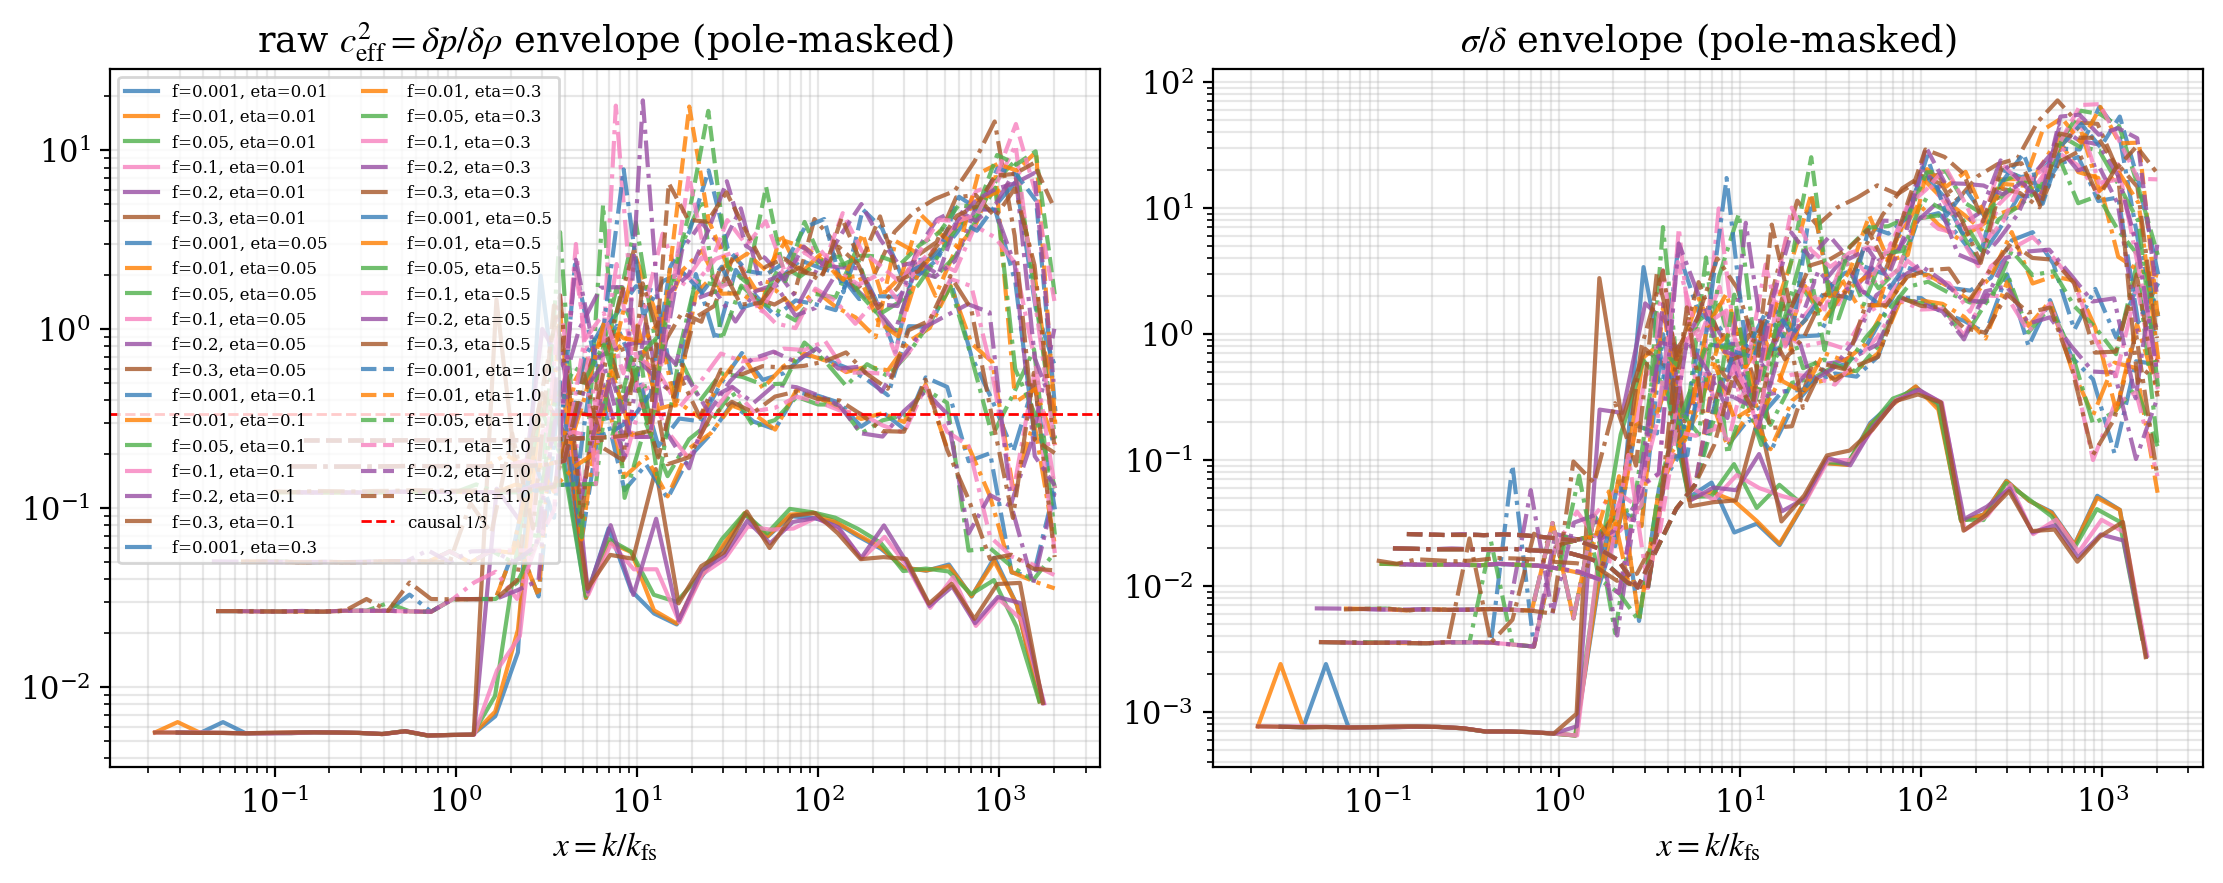

envelope band (pooled-all, fixed-eta):
     ceff2: 38.674, 124.012
   sig_del: 136.380, 151.138


In [5]:
X_EVAL = np.logspace(-1, 3, 60)
ls_eta = {ETA_LIST[0]: '-', ETA_LIST[1]: '-.', ETA_LIST[2]: '-.', ETA_LIST[3]: '-.', ETA_LIST[4]: '-.', ETA_LIST[5]: '--'}
col_f  = {f: qual_colors[i] for i, f in enumerate(F_LIST)}

def band_all(w):
    return collapse_band(X_EVAL, [RESPONSES[k][w] for k in RESPONSES])[1]
def band_fixed_eta(w):
    return float(np.nanmax([collapse_band(X_EVAL, [RESPONSES[(f, e)][w] for f in F_LIST])[1]
                            for e in ETA_LIST]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for (f, eta), r in RESPONSES.items():
    for ax, w in zip(axes, ('ceff2', 'sig_del')):
        x, env = r[w]
        if x.size:
            ax.loglog(x, env, ls_eta[eta], color=col_f[f], alpha=0.8,
                      label='f={}, eta={}'.format(f, eta))
axes[0].axhline(1./3., color='red', ls='--', lw=1.0, label=r'causal $1/3$')
axes[0].set_title(r'raw $c_{\rm eff}^2=\delta p/\delta\rho$ envelope (pole-masked)')
axes[1].set_title(r'$\sigma/\delta$ envelope (pole-masked)')
for ax in axes:
    ax.set_xlabel(r'$x=k/k_{\rm fs}$'); ax.grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=6, ncol=2); plt.show()

band = {w: (band_all(w), band_fixed_eta(w)) for w in ('ceff2', 'sig_del')}
print('envelope band (pooled-all, fixed-eta):')
for w in ('ceff2', 'sig_del'):
    print('  {:>8}: {:.3f}, {:.3f}'.format(w, *band[w]))

## Task 5 - band vs x + kinematic cross-check

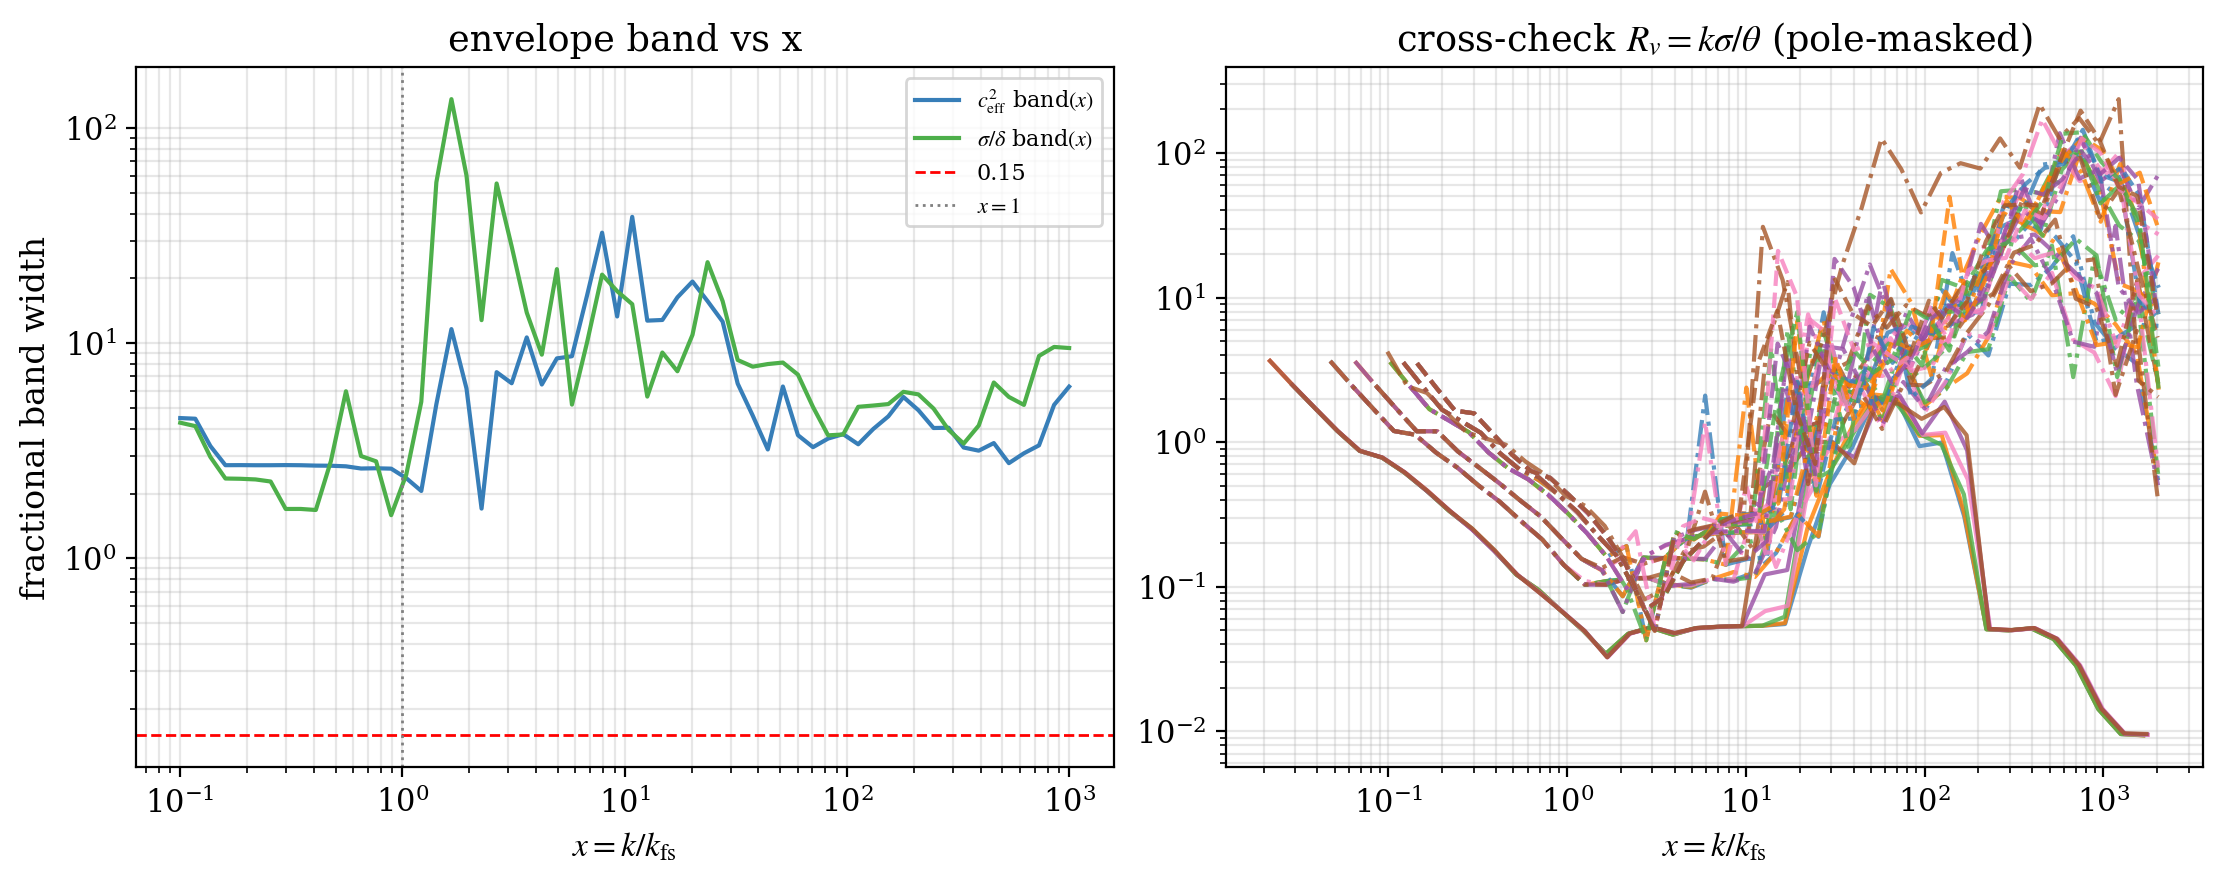

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
bc, _ = collapse_band(X_EVAL, [RESPONSES[k]['ceff2']   for k in RESPONSES])
bs, _ = collapse_band(X_EVAL, [RESPONSES[k]['sig_del'] for k in RESPONSES])
axes[0].loglog(X_EVAL, bc, '-', color=qual_colors[0], label=r'$c_{\rm eff}^2$ band$(x)$')
axes[0].loglog(X_EVAL, bs, '-', color=qual_colors[2], label=r'$\sigma/\delta$ band$(x)$')
axes[0].axhline(0.15, color='red', ls='--', lw=1.0, label='0.15')
axes[0].axvline(1.0, color='gray', ls=':', lw=1.0, label=r'$x=1$')
axes[0].set_title('envelope band vs x'); axes[0].set_xlabel(r'$x=k/k_{\rm fs}$')
axes[0].set_ylabel('fractional band width'); axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend(fontsize=8)
for (f, eta), r in RESPONSES.items():
    x, env = r['Rv']
    if x.size:
        axes[1].loglog(x, env, ls_eta[eta], color=col_f[f], alpha=0.8)
axes[1].set_title(r'cross-check $R_v=k\sigma/\theta$ (pole-masked)')
axes[1].set_xlabel(r'$x=k/k_{\rm fs}$'); axes[1].grid(True, which='both', alpha=0.3)
plt.show()

## Task 6 - plateau closure `ceff2(a) = min(max(ca2(a), c_fs), 1/3)`

The binned **median** `ceff2` is flat over the bulk (`c_fs`), and rises back toward `ca2 -> ~1` at very high `x` (relativistic birth, earliest times) - there the **causal cap 1/3** takes over. That high-x region maps to early times when the daughter density is negligible, so the cap is both correct and harmless for `P(k)` at `k<=1`. `c_fs` = median pole-masked `ceff2` over `x in [0.3, 500]`, pooled over `f`.

**Update (2026-07-15):** the left panel now overlays the newest closure, `ncdm_ceff2_mode = 3` (eta-law plateau `ceff2_f_eta`, nb18 Stage-B fit `A0 = 0.5223`, `B = 0`), replacing the ad-hoc `test_ceff` curve; the right panel compares the measured `c_fs(eta)` points against the mode-3 law directly. Keep `A0_ETA_NB18` in sync with nb18 Stage B.

**(v2, 2026-07-15):** the plotted model line is now the *constant* eta-law plateau only -- the ca2-floor/cap rise at `x >~ 200` lives entirely in the untrusted `x > 30` birth transient and was visually misleading; the full floor/cap form remains what CLASS implements and what the residual table scores. A third panel shows the background evolution of `k_fs(a)` against `aH(a)` per eta.

**(v3, 2026-07-15):** the constant plateau is now also implemented in CLASS as `ncdm_ceff2_mode = 4` (mode-3 eta-law, no adiabatic floor; needs rebuild). Third panel replaced: `c_g^2(a)` per eta against the eta-law plateau levels -- the mode-3 floor binds exactly while the solid curve is above its dashed line, which is the warm post-trigger transient where the measured ceff2 sits at/below the plateau; mode 4 removes that overestimate. Pre-production samples (`a < a_t/2`) are masked (k_fss guard values).

**(v4, 2026-07-15):** finer q-grid rerun shows the data TRACKING the pooled cg2 dip at x ~ 50-300 that it previously ignored -- the frozen-plateau reading may have been a resolution artifact and `cs2 = cg2` (pure adiabatic, sourced Eq-36) is back in play. The x-pooled panels cannot decide this at late times (bin medians are mid-time dominated), so a fixed-k time-slice cell follows the plot: ceff2(a) at fixed k vs cg2(a) vs the eta-law level.

**(v5):** slice cell quantified -- per-k binned medians overlaid on the scatter, plus a ceff2_median/cg2 ratio table (median + 16-84% band) over the post-production window a >= 0.3.

In [7]:
def binned_samples(eta, n_bins=30, min_per_bin=4):
    """Pool pole-masked (x, ca2, ceff2) over f at this eta; robust median per log-x bin."""
    xs, cas, ces = [], [], []
    for f in F_LIST:
        for k, s in SERIES[(f, eta)].items():
            g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
            if not np.any(g):
                continue
            x = k / s['k_fs'][g]
            ca2 = ca2_from_kfs(s['k_fs'][g], s['aH'][g])
            ce = np.abs(mask_small_denom(s['dpr'][g], s['delta'][g], DROP_FRAC))
            m = np.isfinite(ce) & (ce > 0)
            xs.append(x[m]); cas.append(ca2[m]); ces.append(ce[m])
    x = np.concatenate(xs); ca2 = np.concatenate(cas); ce = np.concatenate(ces)
    edges = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)
    xb, cab, deb = [], [], []
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() >= min_per_bin:
            xb.append(np.sqrt(edges[b]*edges[b+1]))
            cab.append(np.median(ca2[sel])); deb.append(np.median(ce[sel]))
    return np.array(xb), np.array(cab), np.array(deb)

def plateau_cfs_single(ser, x_lo=0.3, x_hi=500.0):
    """Plateau c_fs for ONE config: median pole-masked ceff2 over the flat window."""
    vals = []
    for k, s in ser.items():
        g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
        if not np.any(g):
            continue
        x = k / s['k_fs'][g]
        ce = np.abs(mask_small_denom(s['dpr'][g], s['delta'][g], DROP_FRAC))
        m = np.isfinite(ce) & (ce > 0) & (x >= x_lo) & (x <= x_hi)
        if np.any(m):
            vals.append(ce[m])
    return float(np.median(np.concatenate(vals))) if vals else float('nan')

def plateau_cfs(eta):
    """c_fs(eta) pooled over f (kappa=6, a_t=0.13 baseline configs)."""
    vals = [plateau_cfs_single(SERIES[(f, eta)]) for f in F_LIST]
    return float(np.median(vals))

BIN = {eta: binned_samples(eta) for eta in ETA_LIST}
CFS = {eta: plateau_cfs(eta) for eta in ETA_LIST}
print('plateau c_fs(eta) =', {e: round(CFS[e], 4) for e in ETA_LIST})
print('all below causal 1/3:', all(CFS[e] < 1./3. for e in ETA_LIST),
      '| monotone in eta:', bool(np.all(np.diff([CFS[e] for e in ETA_LIST]) > 0)))

plateau c_fs(eta) = {0.01: 0.0052, 0.05: 0.0257, 0.1: 0.0491, 0.3: 0.1265, 0.5: 0.1782, 1.0: 0.2465}
all below causal 1/3: True | monotone in eta: True


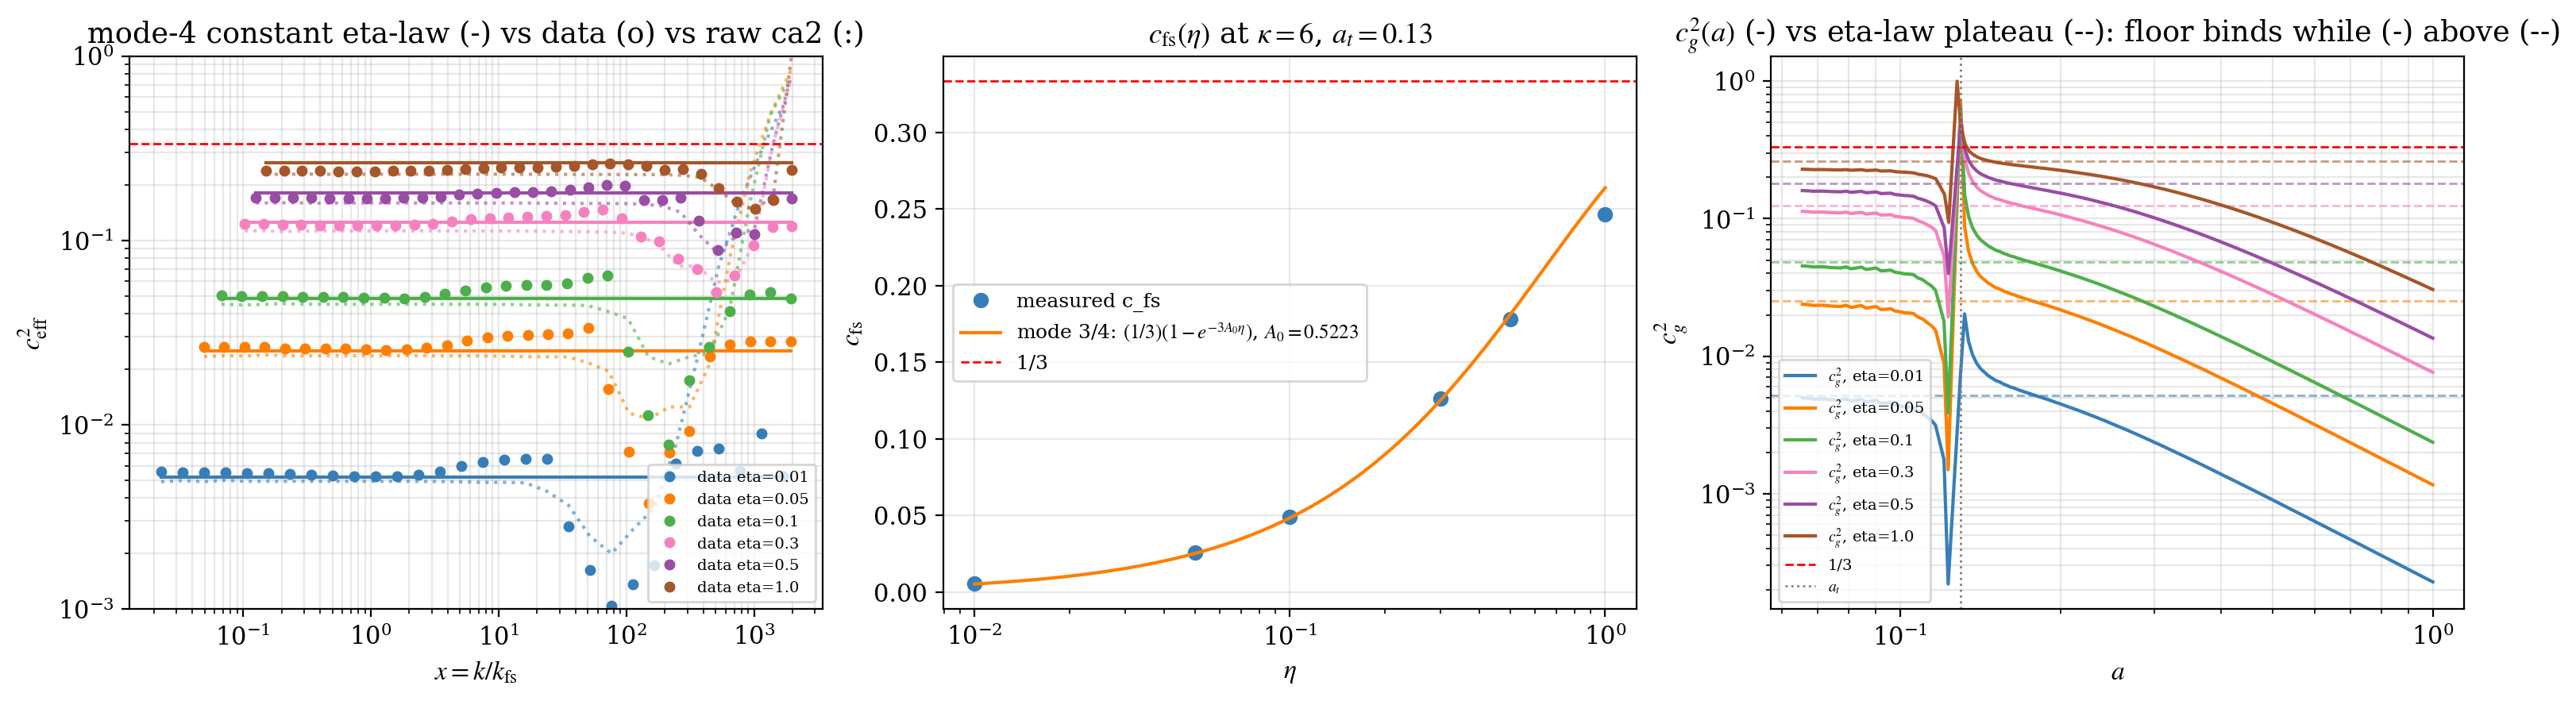

plateau log-RMS residual (x in [0.3,500], lower is better):
  eta=0.01: measured-plateau 0.689 | mode-3 eta-law 0.685 | old sqrt/W 0.997
  eta=0.05: measured-plateau 0.637 | mode-3 eta-law 0.630 | old sqrt/W 0.732
  eta=0.1: measured-plateau 0.621 | mode-3 eta-law 0.616 | old sqrt/W 0.657
  eta=0.3: measured-plateau 0.188 | mode-3 eta-law 0.185 | old sqrt/W 0.220
  eta=0.5: measured-plateau 0.089 | mode-3 eta-law 0.094 | old sqrt/W 0.108
  eta=1.0: measured-plateau 0.033 | mode-3 eta-law 0.080 | old sqrt/W 0.063


In [8]:
# Newest closure (2026-07-15): ncdm_ceff2_mode = 3 -- plateau driven directly by the
# injection kick eta via ceff2_f_eta (nb18 Stage-B fit).
# Plotted model line = the CONSTANT eta-law plateau only (== ncdm_ceff2_mode = 4,
# added 2026-07-15: mode-3 plateau with NO adiabatic floor). The floor/cap form
# min(max(ca2, c_fs3), 1/3) is mode 3 as CLASS implements it and is kept for the
# residual table (model_eta_mode3); panel 3 shows where the floor binds.
A0_ETA_NB18, B_F_NB18 = 0.5223, 0.0   # KEEP IN SYNC with nb18 Stage B output

def model_plateau(ca2, eta):
    """Measured-plateau closure: min(max(ca2, c_fs), 1/3) with the per-eta fitted CFS."""
    return np.minimum(np.maximum(np.asarray(ca2, float), CFS[eta]), 1./3.)

def model_eta_mode3(ca2, eta):
    """Mode-3 closure as CLASS implements it (floor/cap around the eta-law plateau)."""
    c_fs3 = ceff2_f_eta(0.0, eta, A0=A0_ETA_NB18, B=B_F_NB18)
    return np.minimum(np.maximum(np.asarray(ca2, float), c_fs3), 1./3.)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3), constrained_layout=True)

# --- panel 0: data vs constant eta-law plateau (= mode 4) ---
for eta, c in zip(ETA_LIST, qual_colors):
    xb, cab, deb = BIN[eta]
    c_fs3 = ceff2_f_eta(0.0, eta, A0=A0_ETA_NB18, B=B_F_NB18)
    axes[0].loglog(xb, deb, "o", color=c, ms=4, label="data eta={}".format(eta))
    axes[0].loglog([xb.min(), xb.max()], [c_fs3, c_fs3], "-", color=c)
    axes[0].loglog(xb, np.abs(cab), ":", color=c, alpha=0.6)
axes[0].axhline(1./3., color="red", ls="--", lw=1.0)
axes[0].set_title("mode-4 constant eta-law (-) vs data (o) vs raw ca2 (:)")
axes[0].set_xlabel(r"$x=k/k_{\rm fs}$"); axes[0].set_ylabel(r"$c_{\rm eff}^2$")
axes[0].set_ylim(1e-3, 1)
axes[0].grid(True, which="both", alpha=0.3); axes[0].legend(fontsize=7)

# --- panel 1: c_fs(eta): measured points vs the eta-law ---
eta_points = np.array(ETA_LIST)
cfs_points = np.array([CFS[e] for e in ETA_LIST])
eta_grid = np.logspace(np.log10(eta_points.min()), np.log10(eta_points.max()), 200)
axes[1].plot(eta_points, cfs_points, "o", color=qual_colors[0], label="measured c_fs")
axes[1].plot(eta_grid, ceff2_f_eta(0.0, eta_grid, A0=A0_ETA_NB18, B=B_F_NB18), "-",
             color=qual_colors[1],
             label=r"mode 3/4: $(1/3)(1-e^{{-3A_0\eta}})$, $A_0={:.4f}$".format(A0_ETA_NB18))
axes[1].axhline(1./3., color="red", ls="--", lw=1.0, label="1/3")
axes[1].set_xscale("log")
axes[1].set_title(r"$c_{\rm fs}(\eta)$ at $\kappa=6$, $a_t=0.13$")
axes[1].set_xlabel(r"$\eta$"); axes[1].set_ylabel(r"$c_{\rm fs}$")
axes[1].grid(alpha=0.3); axes[1].legend()

# --- panel 2: adiabatic c_g^2(a) vs the eta-law plateau: where does the mode-3
#     floor bind? ca2 = (3/2)(aH/k_fs)^2 from the stored background series;
#     pre-production samples (a < a_t/2) are masked -- k_fss diagnostics are
#     guard values there (the spikes in the old k_fs panel). ---
f_ref = 0.1
for eta, c in zip(ETA_LIST, qual_colors):
    series_by_k = SERIES[(f_ref, eta)]
    one_k = series_by_k[sorted(series_by_k.keys())[0]]   # background quantities, k-independent
    good = (np.isfinite(one_k["k_fs"]) & (one_k["k_fs"] > 0)
            & np.isfinite(one_k["aH"]) & (one_k["a"] >= 0.5*A_T))
    ca2_of_a = ca2_from_kfs(one_k["k_fs"][good], one_k["aH"][good])
    axes[2].loglog(one_k["a"][good], ca2_of_a, "-", color=c,
                   label=r"$c_g^2$, eta={}".format(eta))
    c_fs3 = ceff2_f_eta(0.0, eta, A0=A0_ETA_NB18, B=B_F_NB18)
    axes[2].axhline(c_fs3, color=c, ls="--", lw=1.0, alpha=0.6)
axes[2].axhline(1./3., color="red", ls="--", lw=1.0, label="1/3")
axes[2].axvline(A_T, color="0.5", ls=":", lw=1, label=r"$a_t$")
axes[2].set_title(r"$c_g^2(a)$ (-) vs eta-law plateau (--): floor binds while (-) above (--)")
axes[2].set_xlabel(r"$a$"); axes[2].set_ylabel(r"$c_g^2$")
axes[2].grid(True, which="both", alpha=0.3); axes[2].legend(fontsize=7)
plt.show()

print("plateau log-RMS residual (x in [0.3,500], lower is better):")
for eta in ETA_LIST:
    xb, cab, deb = BIN[eta]; W = 1 - 2*eps_acc_of_eta(eta)
    m = (xb >= 0.3) & (xb <= 500)
    r_fit  = np.sqrt(np.mean((np.log(model_plateau(cab[m], eta)) - np.log(deb[m]))**2))
    r_eta3 = np.sqrt(np.mean((np.log(model_eta_mode3(cab[m], eta)) - np.log(deb[m]))**2))
    r_old  = np.sqrt(np.mean((np.log(np.abs(cab[m]*(1 + 0.2*W*np.sqrt(xb[m])))) - np.log(deb[m]))**2))
    print("  eta={}: measured-plateau {:.3f} | mode-3 eta-law {:.3f} | old sqrt/W {:.3f}".format(
        eta, r_fit, r_eta3, r_old))


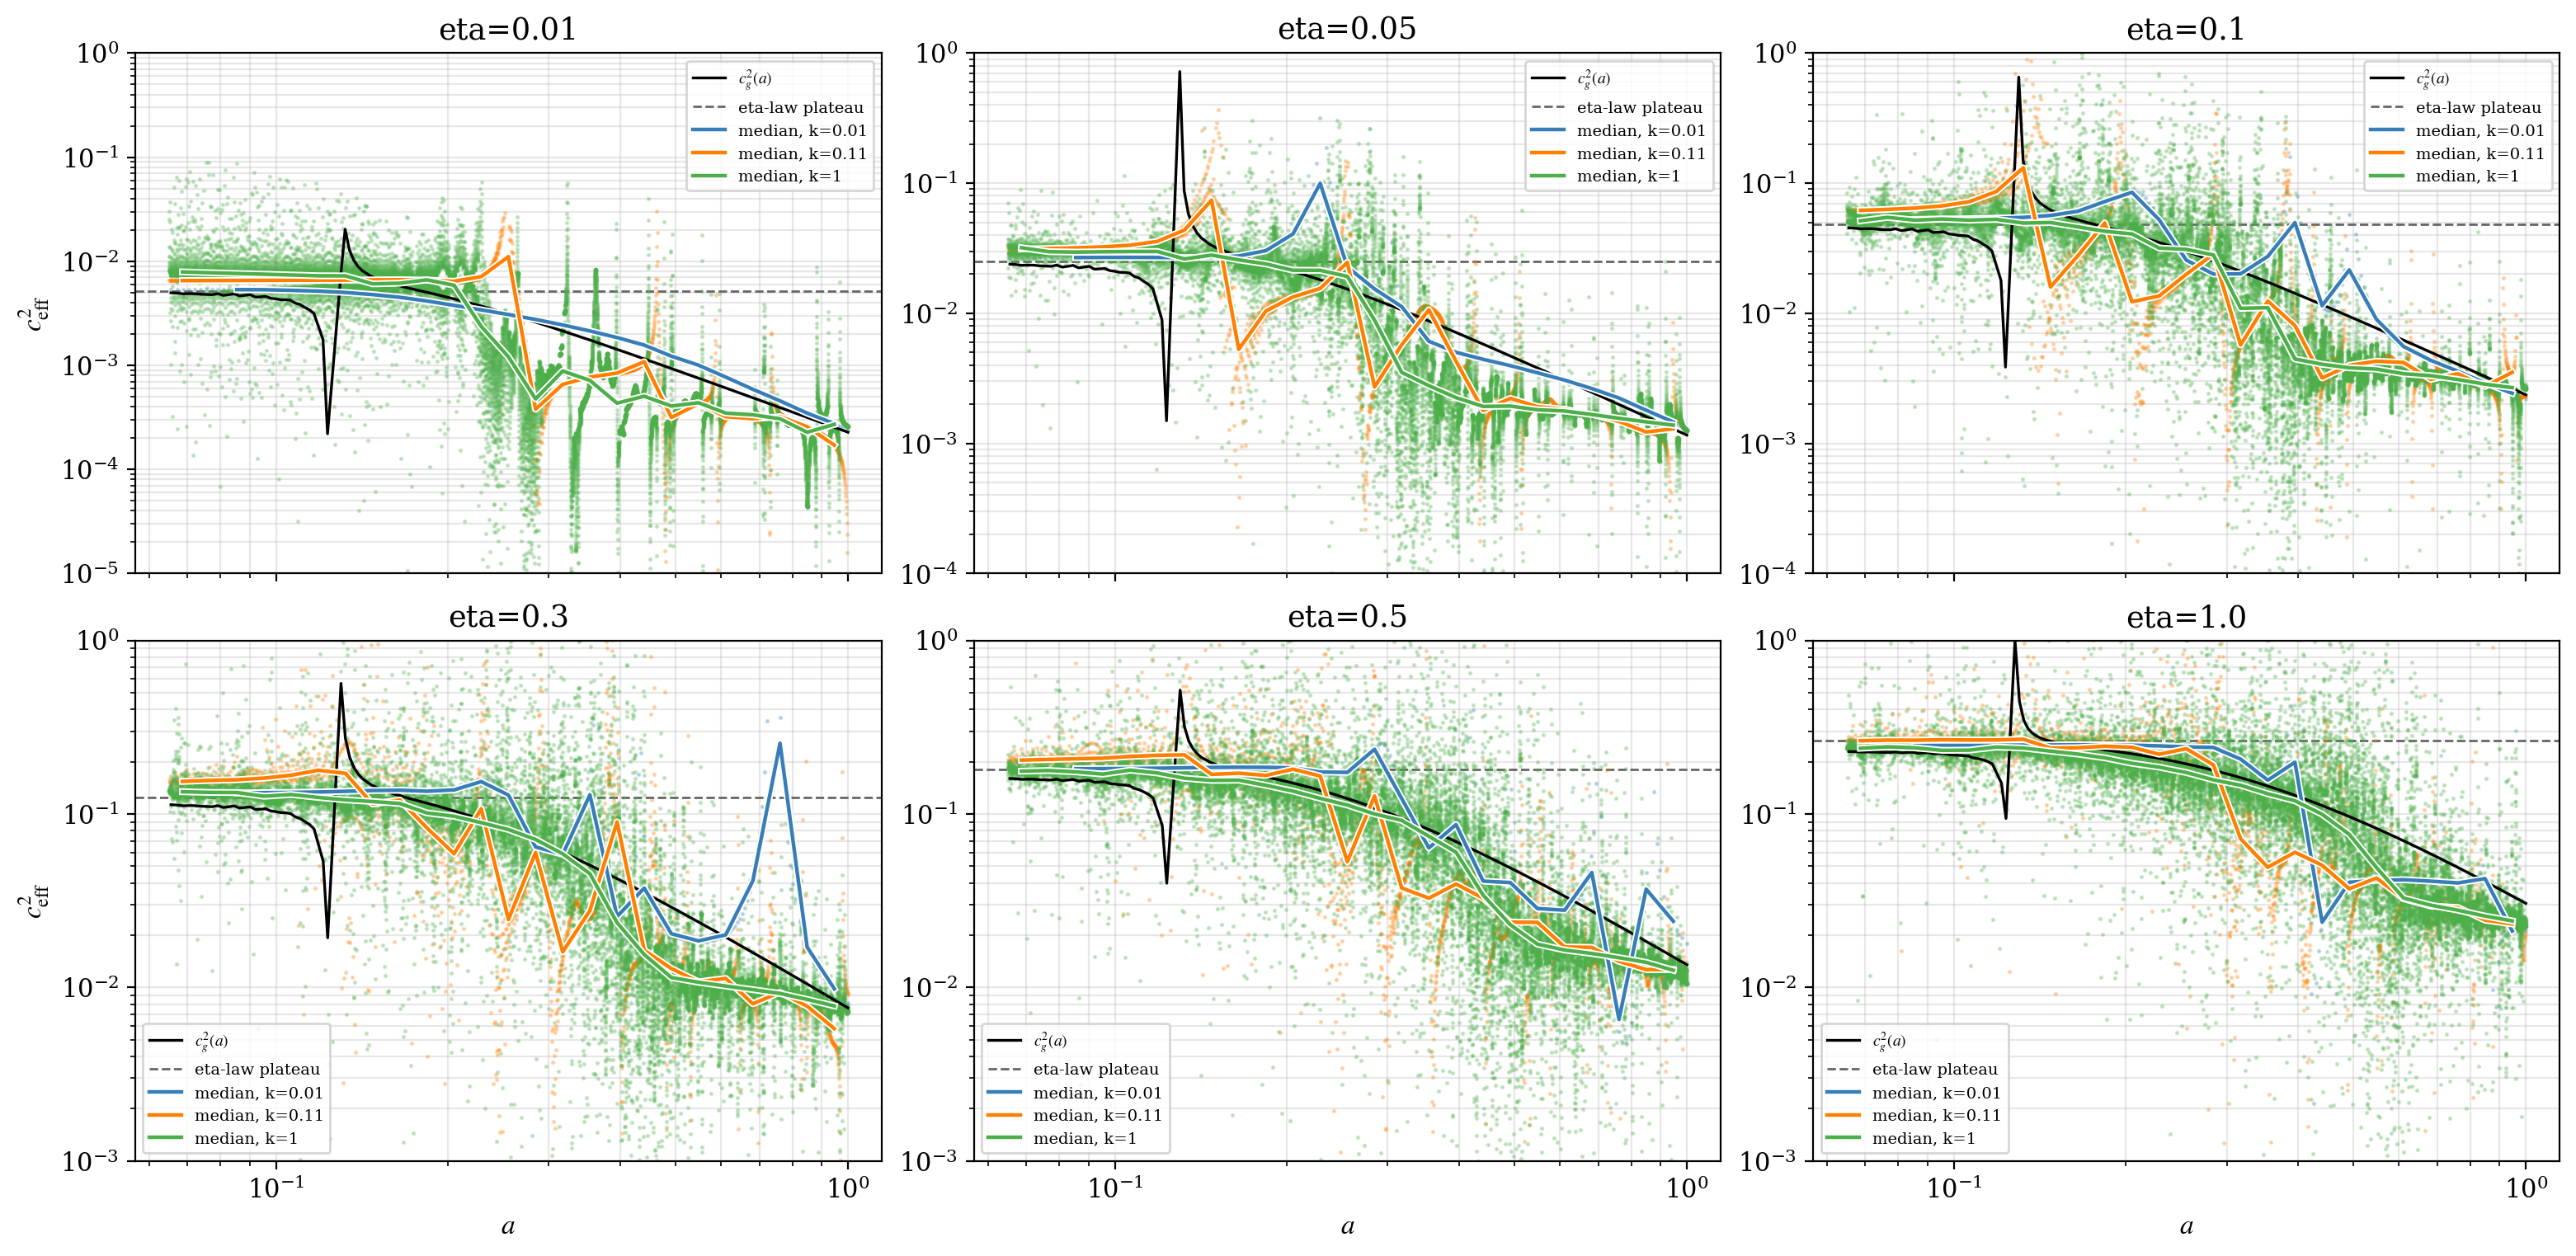

ceff2_median / cg2 over a in [0.3, 1] (adiabatic = ~1 within the band):
  eta      k     median    16%     84%
   0.01   0.01     1.22    1.12    1.32
   0.01   0.11     0.59    0.40    0.81
   0.01      1     0.57    0.41    0.74
   0.05   0.01     1.00    0.74    1.12
   0.05   0.11     0.60    0.49    0.86
   0.05      1     0.48    0.33    0.83
    0.1   0.01     0.96    0.89    1.86
    0.1   0.11     0.62    0.36    0.84
    0.1      1     0.55    0.38    0.81
    0.3   0.01     1.06    0.75    2.57
    0.3   0.11     0.55    0.45    0.73
    0.3      1     0.61    0.45    0.91
    0.5   0.01     0.83    0.70    1.63
    0.5   0.11     0.57    0.45    0.65
    0.5      1     0.66    0.48    0.89
      1   0.01     0.70    0.47    1.16
      1   0.11     0.47    0.42    0.59
      1      1     0.72    0.54    0.90


In [9]:
# Fixed-k time slice, quantified: pole-masked ceff2(a) scatter + per-k binned
# medians, with the ratio to cg2(a) tabulated over the post-production window.
# Verdict metric: median and 16-84% band of ceff2_median/cg2 over a in [A_POST, 1]
# -- "~1 within the band" at every (eta, k) = adiabatic closure confirmed.
import matplotlib.patheffects as pe

f_ref = 0.1
k_picks = [K_GRID[0], K_GRID[len(K_GRID)//2], K_GRID[-1]]
N_ABINS, MIN_PER_BIN, A_POST = 25, 5, 0.3

def binned_median_vs_a(a_samples, y_samples, a_lo, a_hi):
    """Robust median of y in log-a bins; bins with < MIN_PER_BIN samples -> NaN."""
    edges = np.logspace(np.log10(a_lo), np.log10(a_hi), N_ABINS + 1)
    centers = np.sqrt(edges[:-1]*edges[1:])
    medians = np.full(N_ABINS, np.nan)
    for i in range(N_ABINS):
        in_bin = (a_samples >= edges[i]) & (a_samples < edges[i+1]) & np.isfinite(y_samples)
        if np.count_nonzero(in_bin) >= MIN_PER_BIN:
            medians[i] = np.median(y_samples[in_bin])
    return centers, medians

summary_rows = []
fig, axes_grid = plt.subplots(2, 3, figsize=(15.5, 7.5), constrained_layout=True, sharex=True)
for ax, eta in zip(axes_grid.ravel(), ETA_LIST):
    series_by_k = SERIES[(f_ref, eta)]
    background_series = series_by_k[sorted(series_by_k.keys())[0]]
    good_bg = (np.isfinite(background_series["k_fs"]) & (background_series["k_fs"] > 0)
               & np.isfinite(background_series["aH"]) & (background_series["a"] >= 0.5*A_T))
    a_bg = background_series["a"][good_bg]
    cg2_bg = ca2_from_kfs(background_series["k_fs"][good_bg], background_series["aH"][good_bg])
    ax.loglog(a_bg, cg2_bg, "k-", lw=1.2, label=r"$c_g^2(a)$", zorder=5)
    c_fs3 = ceff2_f_eta(0.0, eta, A0=A0_ETA_NB18, B=B_F_NB18)
    ax.axhline(c_fs3, color="0.4", ls="--", lw=1.0, label="eta-law plateau")
    for k_value, color in zip(k_picks, qual_colors):
        nearest_k = min(series_by_k.keys(), key=lambda kk: abs(kk - k_value))
        s = series_by_k[nearest_k]
        good = np.isfinite(s["delta"]) & (s["a"] >= 0.5*A_T)
        ceff2_series = np.abs(mask_small_denom(s["dpr"][good], s["delta"][good], DROP_FRAC))
        a_series = s["a"][good]
        ax.loglog(a_series, ceff2_series, ".", color=color, ms=2, alpha=0.25)
        a_centers, ceff2_medians = binned_median_vs_a(a_series, ceff2_series, 0.5*A_T, 1.0)
        ax.loglog(a_centers, np.abs(ceff2_medians), "-", color=color, lw=1.6,
                  label="median, k={:.2g}".format(nearest_k), zorder=6, path_effects=[pe.withStroke(linewidth=3, foreground="white")])
        # ratio to cg2 over the post-production window
        cg2_at_centers = np.interp(np.log(a_centers), np.log(a_bg), cg2_bg)
        post = (a_centers >= A_POST) & np.isfinite(ceff2_medians) & (cg2_at_centers > 0)
        ratios = ceff2_medians[post]/cg2_at_centers[post]
        if ratios.size:
            summary_rows.append((eta, nearest_k, np.median(ratios),
                                 np.percentile(ratios, 16), np.percentile(ratios, 84)))
        else:
            summary_rows.append((eta, nearest_k, np.nan, np.nan, np.nan))
    ax.set_title("eta={}".format(eta))
    if eta ==0.01:
        ylim_min = 1e-5
    elif eta == 0.05 or eta == 0.1:
        ylim_min = 1e-4
    else:
        ylim_min = 1e-3 
    ax.set_ylim(ylim_min, 1)
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=7)
for ax in axes_grid[-1]:
    ax.set_xlabel(r"$a$")
for ax in axes_grid[:, 0]:
    ax.set_ylabel(r"$c_{\rm eff}^2$")
plt.show()

print("ceff2_median / cg2 over a in [{}, 1] (adiabatic = ~1 within the band):".format(A_POST))
print("  eta      k     median    16%     84%")
for eta, k_value, ratio_median, ratio_p16, ratio_p84 in summary_rows:
    print("  {:5g}  {:5.2g}   {:6.2f}   {:5.2f}   {:5.2f}".format(
        eta, k_value, ratio_median, ratio_p16, ratio_p84))


## Task 6c - effective viscosity: is cvis2 = 3 w ca2 right, and does it run with eta?

The adiabatic-ceff2 + dynamical-shear fluid passes P(k) at +-2-3% except the warm corner
(f=0.3, eta=0.5: +5-10% high = under-damped daughter). With ceff2 settled, the sigma
GENERATION coefficient is the last un-measured ansatz. Quasi-static estimate from the
exact hierarchy (generation ~ damping in the free-streaming regime), reusing the cached
SERIES only -- no new runs, no extractor change.

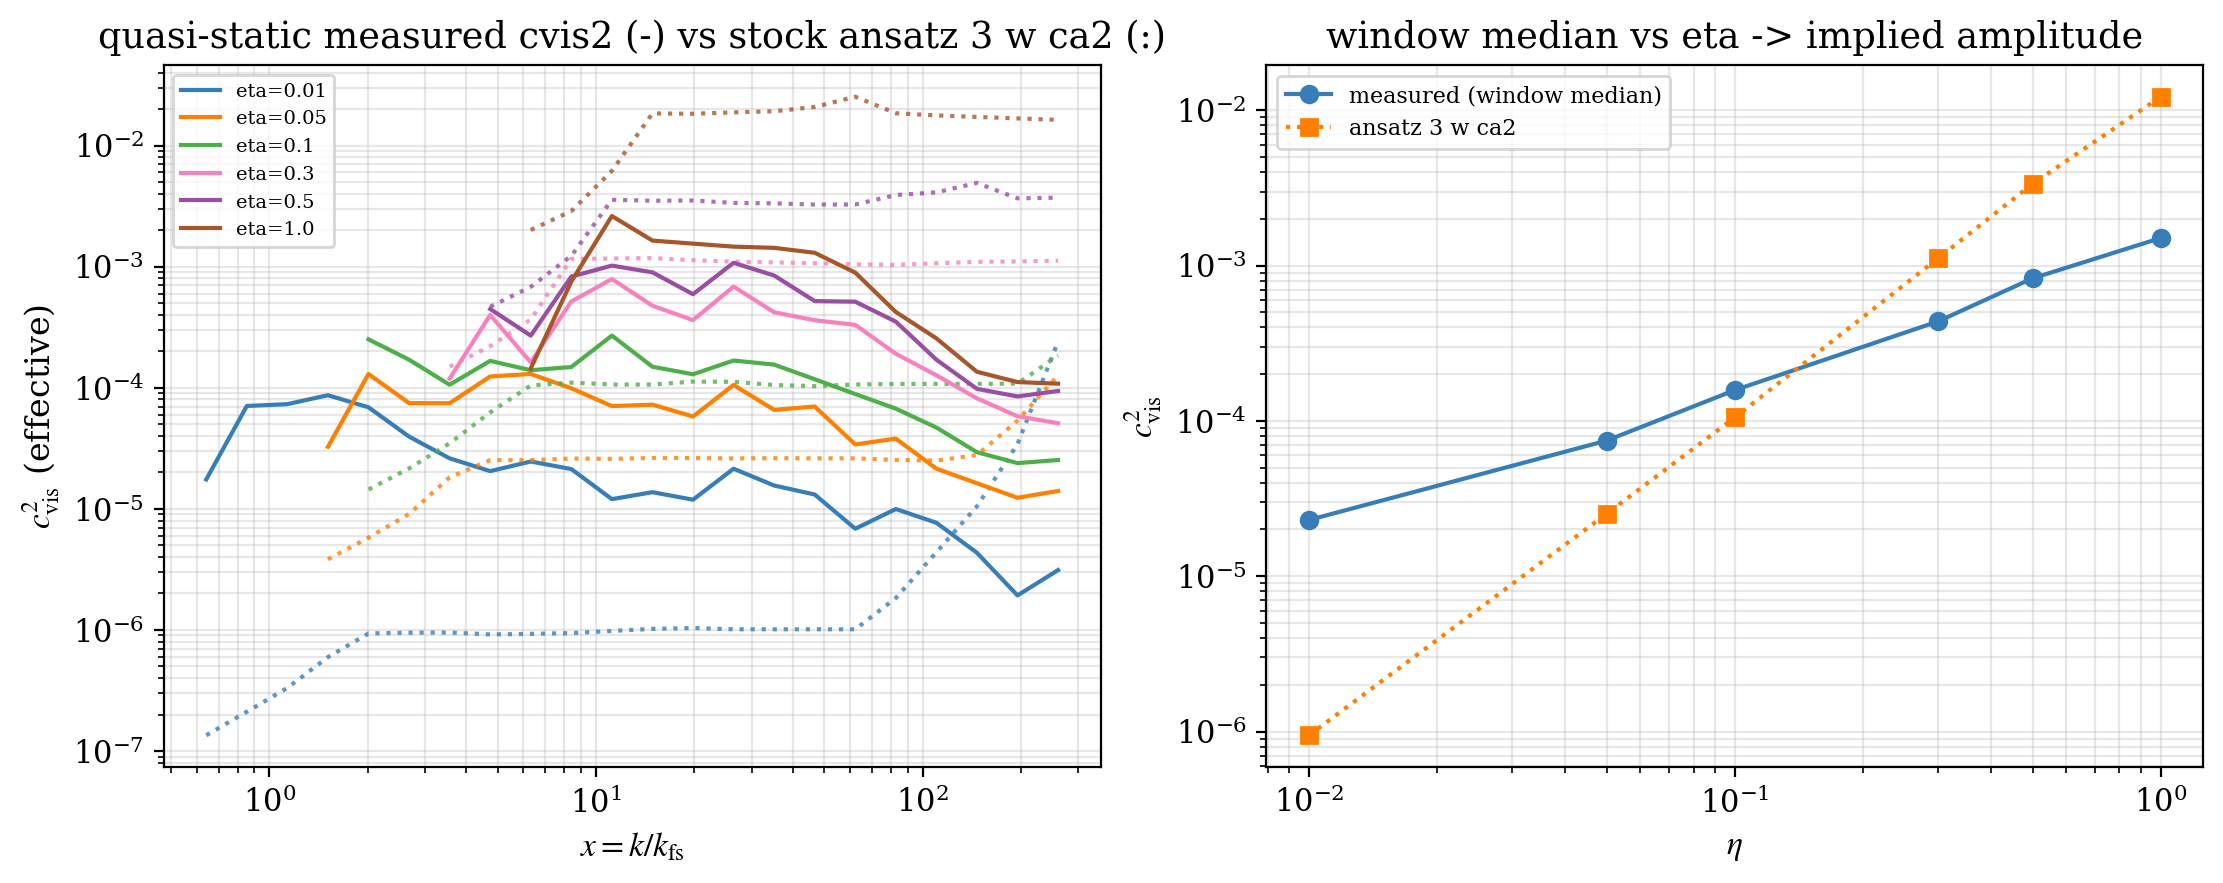

summary over x in [1.0, 30.0]:
  eta    measured     ansatz     A_vis = measured/ansatz
  0.01   2.302e-05  9.450e-07    24.36
  0.05   7.466e-05  2.523e-05     2.96
   0.1   1.579e-04  1.053e-04     1.50
   0.3   4.373e-04  1.114e-03     0.39
   0.5   8.281e-04  3.359e-03     0.25
     1   1.506e-03  1.224e-02     0.12
read-off: A_vis ~ const ~ 1 -> stock ansatz fine; A_vis rising with eta -> the
sigma generation is under-powered at warm eta (the pink under-damping candidate);
caveats: quasi-static balance, metric/(1+w)/Q terms dropped, cold-limit w(ca2)
in the ansatz reference -- treat as a ~30% diagnostic, not a calibration.


In [10]:
# --- Task 6c: effective viscosity diagnostic (2026-07-16) ---
# Is the stock ansatz cvis2 = 3*w*ca2 (feeding the sigma-generation term of the
# dynamical shear equation) right for the accDM daughter, and how does it run
# with eta? Context: adiabatic ceff2 + dynamical sigma passes P(k) at +-2-3%
# except the warm corner (f=0.3, eta=0.5, +5-10% high = under-damped), and the
# generation coefficient is the last un-measured ansatz.
#
# Quasi-static estimate from the exact hierarchy: in the free-streaming regime
#   (8/3)*(cvis2/(1+w))*(theta + h'/2) ~= 3*[H(2/3 - ca2 - pp/3p) + 1/tau + Q]*sigma
# With the O(ca2), Q, metric and (1+w) pieces dropped (a ~30% diagnostic, fine
# for detecting a factor-of-few eta trend):
#   cvis2_eff ~= (3/8)*(2*aH + 3/tau)*sigma/theta.
# Ansatz reference in stored variables: 3*w*ca2 ~= (9/5)*ca2^2 (cold limit
# w ~= (3/5)*ca2 -- degrades for warm eta, noted in the table caveat).
# Same |.| + pole-mask estimator caveats as the ceff2 measurement.

def binned_median_vs_x(x_samples, y_samples, n_bins=28, x_lo=1e-1, x_hi=3e2, min_per_bin=5):
    """Median of y in log-x bins; bins with < min_per_bin finite samples -> NaN."""
    edges = np.logspace(np.log10(x_lo), np.log10(x_hi), n_bins + 1)
    centers = np.sqrt(edges[:-1]*edges[1:])
    medians = np.full(n_bins, np.nan)
    for i in range(n_bins):
        in_bin = (x_samples >= edges[i]) & (x_samples < edges[i+1]) & np.isfinite(y_samples)
        if np.count_nonzero(in_bin) >= min_per_bin:
            medians[i] = np.median(y_samples[in_bin])
    return centers, medians

f_ref = 0.1
X_WINDOW_VIS = (1.0, 30.0)   # generation regime scored for the summary
vis_rows = []

fig, (ax_run, ax_eta) = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for eta, color in zip(ETA_LIST, qual_colors):
    x_pool, measured_pool, ansatz_pool = [], [], []
    for k, s in SERIES[(f_ref, eta)].items():
        good = (np.isfinite(s["k_fs"]) & (s["k_fs"] > 0) & np.isfinite(s["aH"])
                & (s["a"] >= A_T))
        if not np.any(good):
            continue
        x = k / s["k_fs"][good]
        ca2 = ca2_from_kfs(s["k_fs"][good], s["aH"][good])
        theta_safe = np.where(s["theta"][good] == 0, np.nan, s["theta"][good])
        sigma_over_theta = np.abs(mask_small_denom(
            s["shear"][good]/theta_safe, s["theta"][good], DROP_FRAC))
        damping_rate = 2.0*s["aH"][good] + 3.0/s["tau"][good]
        x_pool.append(x)
        measured_pool.append((3.0/8.0)*damping_rate*sigma_over_theta)
        ansatz_pool.append(1.8*ca2*ca2)
    x_all = np.concatenate(x_pool)
    x_centers, measured_median = binned_median_vs_x(x_all, np.concatenate(measured_pool))
    _, ansatz_median = binned_median_vs_x(x_all, np.concatenate(ansatz_pool))
    ax_run.loglog(x_centers, measured_median, "-", color=color, label="eta={}".format(eta))
    ax_run.loglog(x_centers, ansatz_median, ":", color=color, alpha=0.8)
    in_window = (x_centers >= X_WINDOW_VIS[0]) & (x_centers <= X_WINDOW_VIS[1])
    measured_window = np.nanmedian(measured_median[in_window])
    ansatz_window = np.nanmedian(ansatz_median[in_window])
    vis_rows.append((eta, measured_window, ansatz_window,
                     measured_window/ansatz_window if ansatz_window > 0 else np.nan))
ax_run.set_xlabel(r"$x=k/k_{\rm fs}$"); ax_run.set_ylabel(r"$c_{\rm vis}^2$ (effective)")
ax_run.set_title("quasi-static measured cvis2 (-) vs stock ansatz 3 w ca2 (:)")
ax_run.grid(True, which="both", alpha=0.3); ax_run.legend(fontsize=7)

eta_values = np.array([row[0] for row in vis_rows])
ax_eta.loglog(eta_values, [row[1] for row in vis_rows], "o-", color=qual_colors[0],
              label="measured (window median)")
ax_eta.loglog(eta_values, [row[2] for row in vis_rows], "s:", color=qual_colors[1],
              label="ansatz 3 w ca2")
ax_eta.set_xlabel(r"$\eta$"); ax_eta.set_ylabel(r"$c_{\rm vis}^2$")
ax_eta.set_title("window median vs eta -> implied amplitude")
ax_eta.grid(True, which="both", alpha=0.3); ax_eta.legend(fontsize=8)
plt.show()

print("summary over x in [{}, {}]:".format(*X_WINDOW_VIS))
print("  eta    measured     ansatz     A_vis = measured/ansatz")
for eta, measured_window, ansatz_window, amplitude in vis_rows:
    print("  {:4g}   {:9.3e}  {:9.3e}   {:6.2f}".format(
        eta, measured_window, ansatz_window, amplitude))
print("read-off: A_vis ~ const ~ 1 -> stock ansatz fine; A_vis rising with eta -> the")
print("sigma generation is under-powered at warm eta (the pink under-damping candidate);")
print("caveats: quasi-static balance, metric/(1+w)/Q terms dropped, cold-limit w(ca2)")
print("in the ansatz reference -- treat as a ~30% diagnostic, not a calibration.")


## Task 7 - sensitivity of the plateau `c_fs` to `kappa` and `a_t`

**Result (first run):** `c_fs` across kappa {2,6,20} = [0.039, 0.031, 0.023] (**50% spread**); across a_t {0.01,0.13,0.5} = [0.0003, 0.031, 0.053] (**170% spread**). So `c_fs(eta)` alone is dead - but the pattern (later birth / broader turn-on -> warmer today -> larger c_fs) is exactly the frozen-dispersion story, tested in Task 8.

In [11]:
ETA_S, F_S = 0.1, 0.1
KAPPA_SWEEP = [2.0, 6.0, 20.0]      # a_t = 0.13 fixed
AT_SWEEP    = [0.01, 0.13, 0.5]     # kappa = 6.0 fixed

def sweep_run(kappa, a_t):
    ser = cached_extract(ETA_S, F_S, kappa=kappa, a_t=a_t)
    Xc, Ce = [], []
    for k, s in ser.items():
        g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
        if not np.any(g):
            continue
        x = k / s['k_fs'][g]
        ce = np.abs(mask_small_denom(s['dpr'][g], s['delta'][g], DROP_FRAC))
        Xc.append(x); Ce.append(ce)
    env = log_upper_envelope(np.concatenate(Xc), np.concatenate(Ce))
    return dict(env=env, cfs=plateau_cfs_single(ser), ser=ser)

SWEEP = {}
for kap in tqdm(KAPPA_SWEEP, desc='kappa'):
    SWEEP[('kappa', kap)] = sweep_run(kap, 0.13)
for at in tqdm(AT_SWEEP, desc='a_t'):
    SWEEP[('a_t', at)] = SWEEP[('kappa', 6.0)] if at == 0.13 else sweep_run(6.0, at)
print('c_fs across kappa {2,6,20}:  ', [round(SWEEP[('kappa', k)]['cfs'], 4) for k in KAPPA_SWEEP])
print('c_fs across a_t {.01,.13,.5}:', [round(SWEEP[('a_t', a)]['cfs'], 4) for a in AT_SWEEP])

a_t: 100%|██████████| 3/3 [00:00<00:00, 26.25it/s]

c_fs across kappa {2,6,20}:   [0.0378, 0.0491, 0.0542]
c_fs across a_t {.01,.13,.5}: [0.0007, 0.0491, 0.0563]


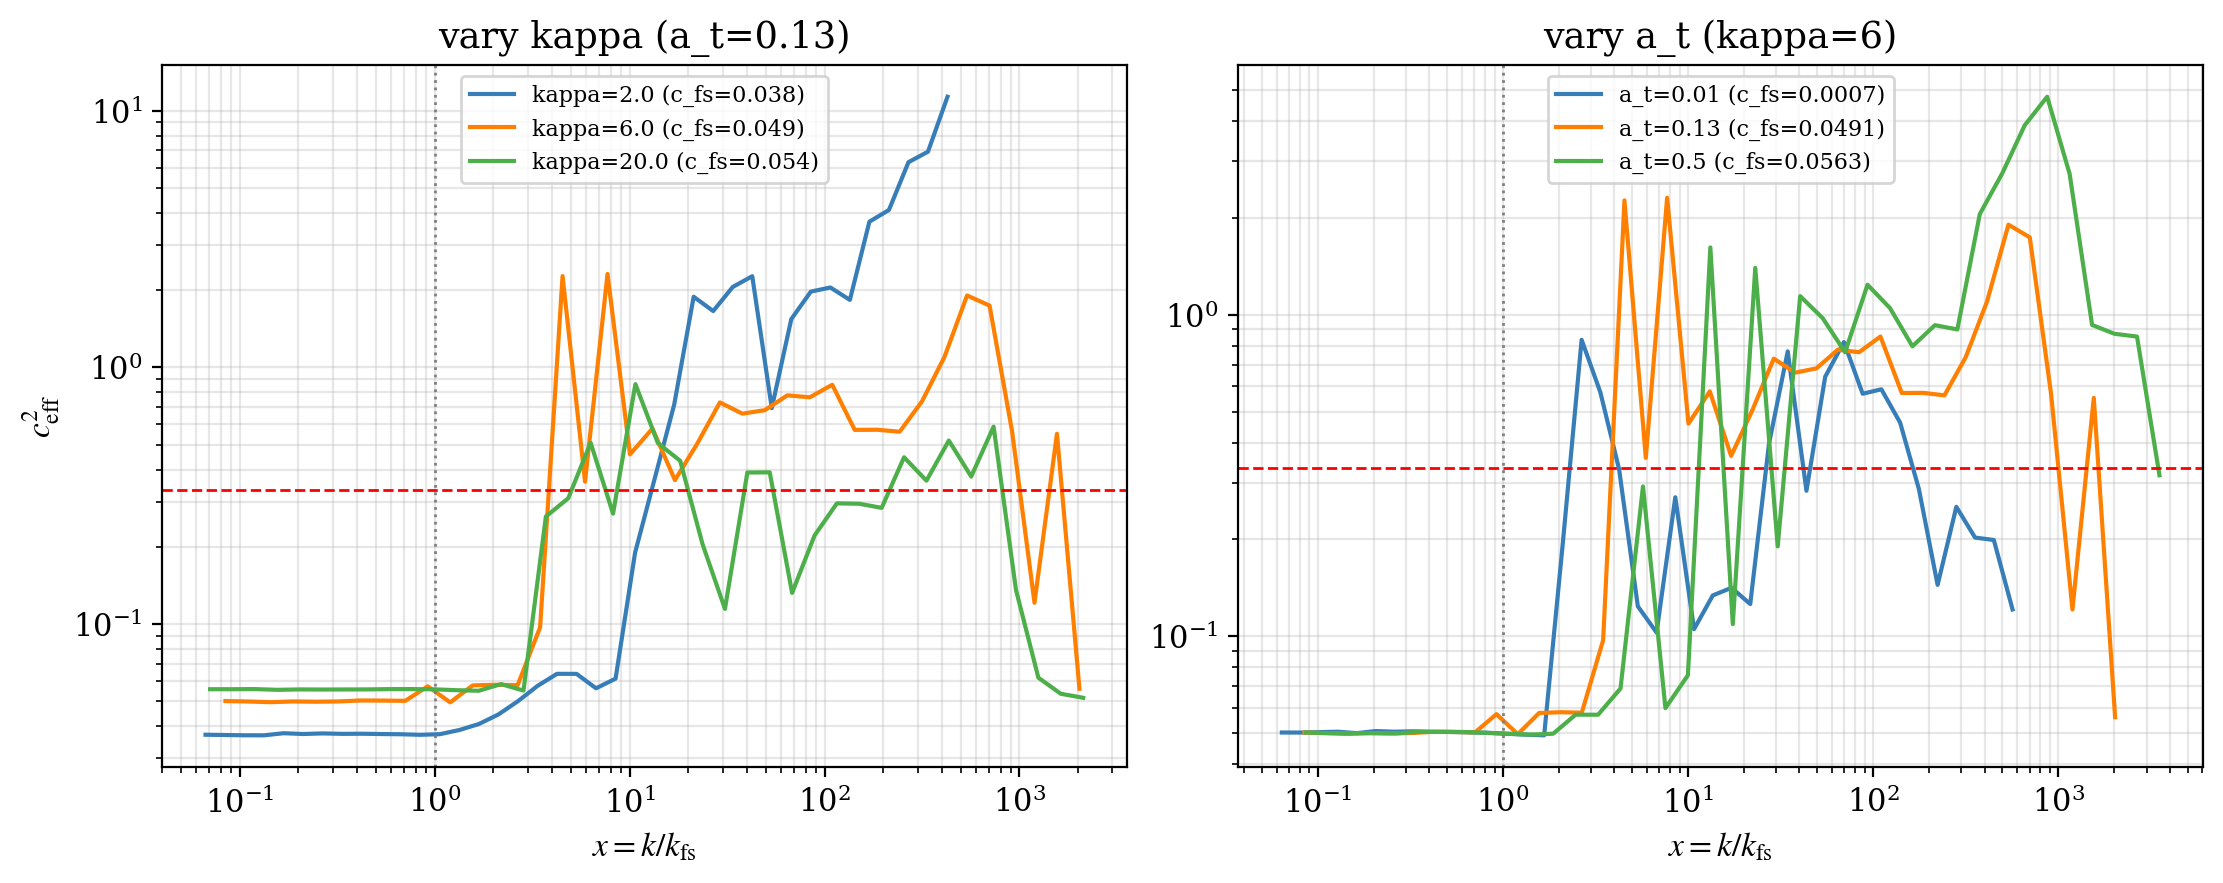

c_fs spread across kappa: 33.4% | across a_t: 113.1%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for kap, c in zip(KAPPA_SWEEP, qual_colors):
    x, env = SWEEP[('kappa', kap)]['env']
    axes[0].loglog(x, env, '-', color=c, label='kappa={} (c_fs={:.3f})'.format(kap, SWEEP[('kappa', kap)]['cfs']))
for at, c in zip(AT_SWEEP, qual_colors):
    x, env = SWEEP[('a_t', at)]['env']
    axes[1].loglog(x, env, '-', color=c, label='a_t={} (c_fs={:.4f})'.format(at, SWEEP[('a_t', at)]['cfs']))
for ax, t in zip(axes, ('vary kappa (a_t=0.13)', 'vary a_t (kappa=6)')):
    ax.axhline(1./3., color='red', ls='--', lw=1.0); ax.axvline(1.0, color='gray', ls=':', lw=1.0)
    ax.set_xlabel(r'$x=k/k_{\rm fs}$'); ax.set_title(t)
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(r'$c_{\rm eff}^2$'); plt.show()

ck = [SWEEP[('kappa', k)]['cfs'] for k in KAPPA_SWEEP]
caa = [SWEEP[('a_t', a)]['cfs'] for a in AT_SWEEP]
print('c_fs spread across kappa: {:.1%} | across a_t: {:.1%}'.format(
    (max(ck)-min(ck))/np.median(ck), (max(caa)-min(caa))/np.median(caa)))

## Task 8 (decisive) - is `c_fs` the frozen background dispersion?

Hypothesis: `c_fs = A * ca2_bg(a=1)` with **one universal constant A**, where `ca2_bg(a=1)` is the daughter's background adiabatic sound speed today (recovered from the last tau-sample of `k_fss_acc`, which CLASS builds from the full evolved PSD - so it carries `eta`, `a_t`, `kappa` automatically). Test across ALL configs: 12 main `(f, eta)` + 4 unique sweep `(kappa, a_t)` points.

- **log-log slope ~ 1 and tight A** -> Phase 2 is parameter-free: `ceff2 = min(max(ca2(a), A*ca2_bg(a0)), 1/3)`, no fitted surface.
- **slope != 1 or wide scatter** -> `c_fs` needs a 3-D `(eta, kappa, a_t)` surface -> cost-benefit vs exact + q(f) schedule (notebook 14) likely favors nb14.

config                       c_fs  ca2_bg(a=1)        A
f=0.001,eta=0.01           0.0052    2.279e-04    22.98
f=0.01,eta=0.01            0.0052    2.279e-04    22.98
f=0.05,eta=0.01            0.0052    2.279e-04    22.98
f=0.1,eta=0.01             0.0052    2.279e-04    22.98
f=0.2,eta=0.01             0.0052    2.279e-04    22.98
f=0.3,eta=0.01             0.0052    2.279e-04    22.98
f=0.001,eta=0.05           0.0257    1.159e-03    22.17
f=0.01,eta=0.05            0.0257    1.159e-03    22.17
f=0.05,eta=0.05            0.0257    1.159e-03    22.17
f=0.1,eta=0.05             0.0257    1.159e-03    22.17
f=0.2,eta=0.05             0.0257    1.159e-03    22.17
f=0.3,eta=0.05             0.0257    1.159e-03    22.16
f=0.001,eta=0.1            0.0492    2.363e-03    20.80
f=0.01,eta=0.1             0.0491    2.363e-03    20.80
f=0.05,eta=0.1             0.0491    2.363e-03    20.79
f=0.1,eta=0.1              0.0491    2.363e-03    20.79
f=0.2,eta=0.1              0.0492    2.363e-03  

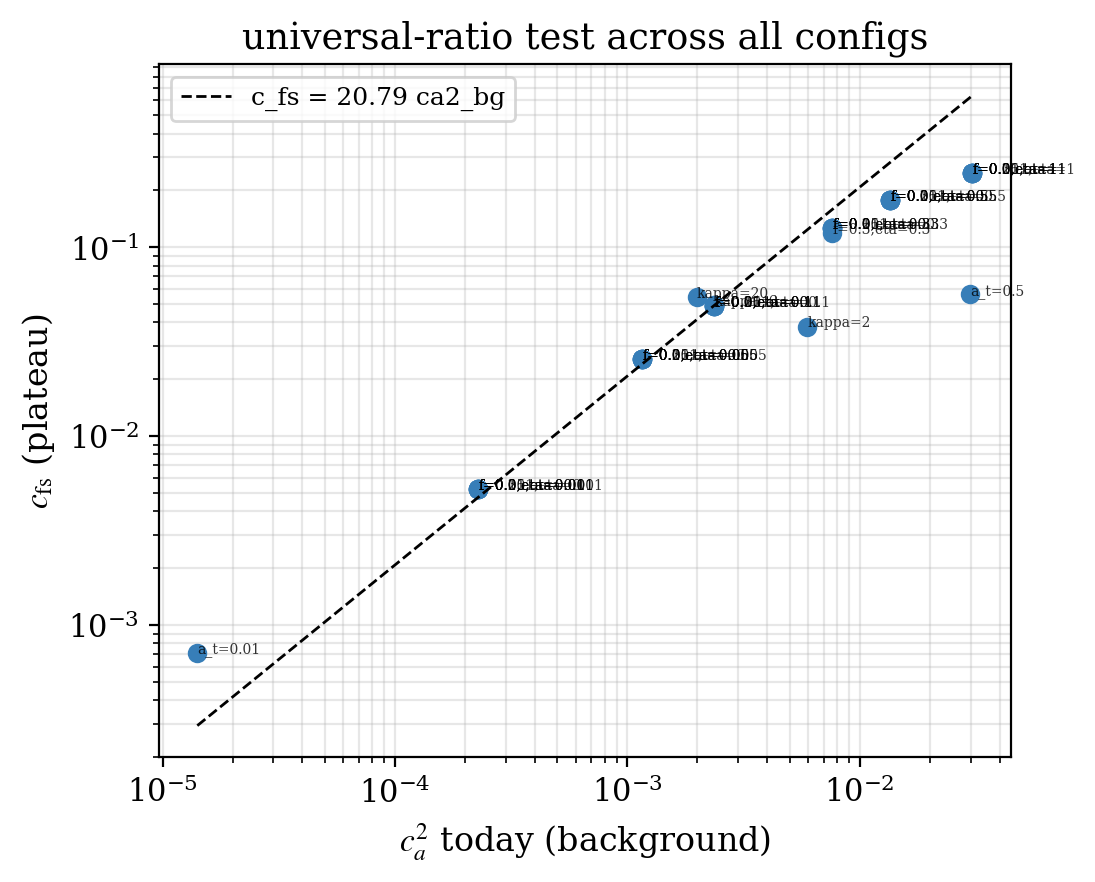

In [13]:
def ca2_today_from_series(ser):
    """Daughter background ca2 at the latest stored tau (median over k)."""
    vals = []
    for k, s in ser.items():
        idx = np.where((s['k_fs'] > 0) & np.isfinite(s['aH']))[0]
        if idx.size:
            i = idx[-1]
            vals.append(float(ca2_from_kfs(s['k_fs'][i], s['aH'][i])))
    return float(np.median(vals)) if vals else float('nan')

CONFIGS = []
for (f, eta), ser in SERIES.items():
    CONFIGS.append(('f={:g},eta={:g}'.format(f, eta), plateau_cfs_single(ser), ca2_today_from_series(ser)))
for (knob, v), d in SWEEP.items():
    if (knob, v) == ('a_t', 0.13):
        continue                                   # duplicate of kappa=6 baseline
    CONFIGS.append(('{}={:g}'.format(knob, v), d['cfs'], ca2_today_from_series(d['ser'])))

labs = [c[0] for c in CONFIGS]
cfs  = np.array([c[1] for c in CONFIGS])
ca0  = np.array([c[2] for c in CONFIGS])
m = np.isfinite(cfs) & np.isfinite(ca0) & (cfs > 0) & (ca0 > 0)
A = cfs[m] / ca0[m]
slope = np.polyfit(np.log(ca0[m]), np.log(cfs[m]), 1)[0]

print('{:<22} {:>10} {:>12} {:>8}'.format('config', 'c_fs', 'ca2_bg(a=1)', 'A'))
for i in np.where(m)[0]:
    print('{:<22} {:>10.4f} {:>12.3e} {:>8.2f}'.format(labs[i], cfs[i], ca0[i], cfs[i]/ca0[i]))
print('\nlog-log slope = {:.2f}  (1.0 = proportional)'.format(slope))
print('A = c_fs/ca2_bg(a=1): median {:.2f}, spread (max-min)/median = {:.1%}'.format(
    float(np.median(A)), float((A.max()-A.min())/np.median(A))))

plt.figure(figsize=(5.5, 4.5))
plt.loglog(ca0[m], cfs[m], 'o', color=qual_colors[0])
xx = np.array([ca0[m].min(), ca0[m].max()])
plt.loglog(xx, np.median(A)*xx, 'k--', lw=1.0, label='c_fs = {:.2f} ca2_bg'.format(float(np.median(A))))
for i in np.where(m)[0]:
    plt.annotate(labs[i], (ca0[i], cfs[i]), fontsize=5, alpha=0.8)
plt.xlabel(r'$c_a^2$ today (background)'); plt.ylabel(r'$c_{\rm fs}$ (plateau)')
plt.title('universal-ratio test across all configs')
plt.grid(True, which='both', alpha=0.3); plt.legend(); plt.show()

## Verdict (measured 2026-07-06)

- **The closure target is right and non-trivial:** the free-streaming plateau sits `A ~ 7-21x` above today's adiabatic `ca2_bg` - genuinely non-adiabatic pressure support, not a re-measurement of `ca2` (answers the "would be weird if adiabatic" concern).
- **Closure form:** `ceff2(a) = min(max(ca2(a), c_fs), 1/3)`; baseline plateau `c_fs = {0.1: 0.0296, 0.3: 0.0949, 1.0: 0.2277}` (kappa=6, a_t=0.13), f-independent to 0.5% up to f=0.3.
- **Universal ratio (Task 8): FAILS strictly.** slope = 0.81, `A = c_fs/ca2_bg(a=1)` median 12.4, spread 159% (A: 1.6 at a_t=0.5 ... 21.5 at a_t=0.01).
- **De-saturation (Task 9):** the eta break (A: 12.5 -> 7.46 at eta=1) is **causal saturation** - `12.4*ca2_bg = 0.38 > 1/3`; the map `c_fs = (1/3)(1-exp(-3 A ca2_bg))` collapses the baseline family to ~15-20%. The **kappa/a_t residual persists** (A_desat ~ 1.8-21): production-history *maturity* - freshly-born daughters contribute adiabatically, not at the plateau - which no background moment can encode (background PSD today doesn't know when each sub-population was born).
- **Consequence for Phase 2:** a background-computable `ncdm_ceff2_mode = 2` = `min(max(ca2, (1/3)(1-exp(-3 A ca2_bg(a0)))), 1/3)` with one constant `A ~ 13` is valid **only where production completed early** (a_t <~ 0.2, kappa >~ 4-6) - and even there a_t=0.01 gives A~21 (possibly a measurement systematic at tiny c_fs; unresolved). Scans that vary `kappa`/`a_t` are NOT covered.
- **Recommendation:** for production parameter scans over `(eta, kappa, a_t, f)` -> **exact + q(f) schedule (notebook 14)**. The fluid closure is an optional fixed-(kappa, a_t) speedup, to be validated by Phase 3 (P(k) over k<=1, f=0.3) before any production use.

**Keep in sync:** `fluid_closure_helpers.py` (unit-tested). Cache: `accDM_scans/nb15_cache/` (bump `CACHE_TAG` after any extractor/params change). `w_sigma`/`w_theta` are zero in exact runs (`memory: w-sigma-zero-in-exact-hierarchy`).

config                    A_raw  A_desat
f=0.001,eta=0.01          22.98    23.16
f=0.01,eta=0.01           22.98    23.16
f=0.05,eta=0.01           22.98    23.16
f=0.1,eta=0.01            22.98    23.16
f=0.2,eta=0.01            22.98    23.16
f=0.3,eta=0.01            22.98    23.16
f=0.001,eta=0.05          22.17    23.07
f=0.01,eta=0.05           22.17    23.07
f=0.05,eta=0.05           22.17    23.07
f=0.1,eta=0.05            22.17    23.07
f=0.2,eta=0.05            22.17    23.07
f=0.3,eta=0.05            22.16    23.06
f=0.001,eta=0.1           20.80    22.50
f=0.01,eta=0.1            20.80    22.50
f=0.05,eta=0.1            20.79    22.49
f=0.1,eta=0.1             20.79    22.49
f=0.2,eta=0.1             20.80    22.50
f=0.3,eta=0.1             20.80    22.51
f=0.001,eta=0.3           16.59    20.86
f=0.01,eta=0.3            16.60    20.87
f=0.05,eta=0.3            16.59    20.86
f=0.1,eta=0.3             16.59    20.86
f=0.2,eta=0.3             16.59    20.86
f=0.3,eta=0.3   

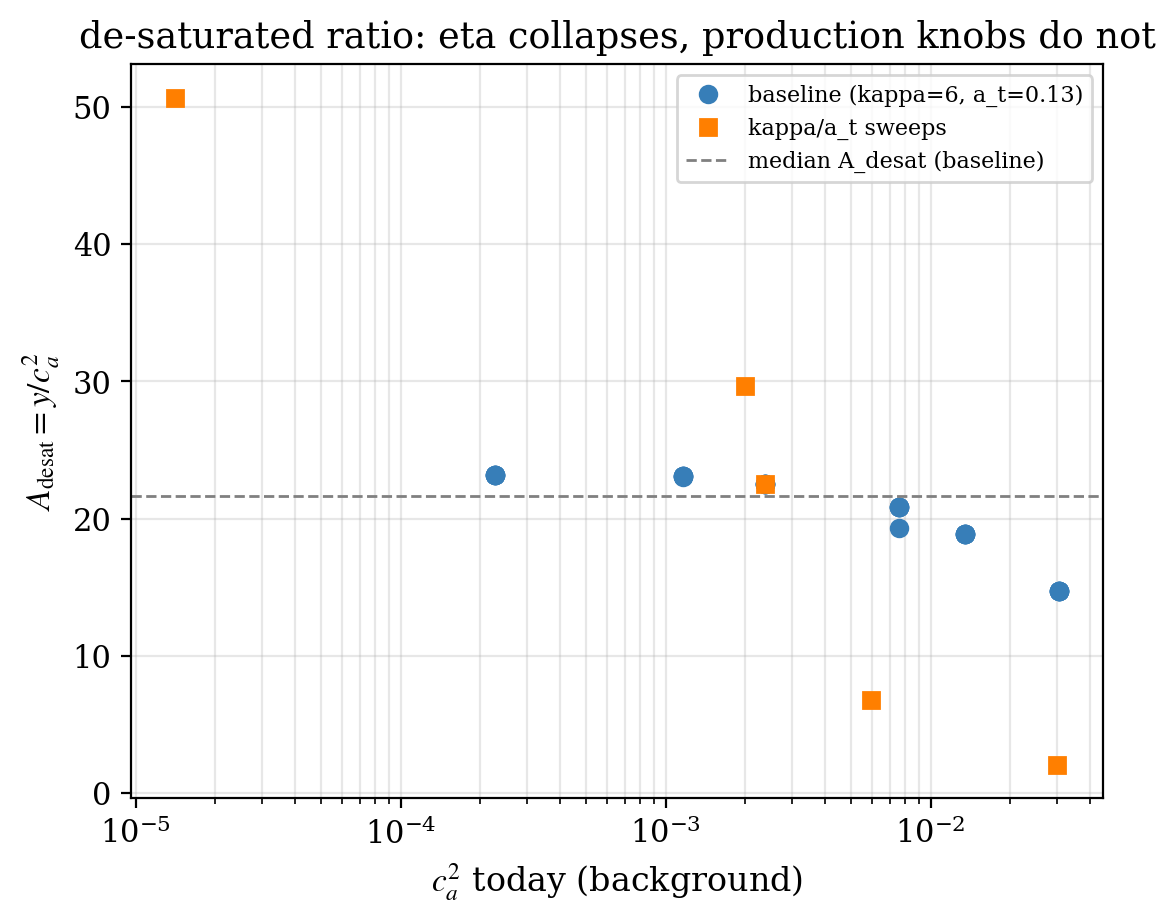

In [14]:
# De-saturation: c_fs = (1/3)(1 - exp(-3 y))  =>  y = -ln(1 - 3 c_fs)/3.
# Uses the cfs/ca0/labs/m arrays from Task 8 - no new CLASS runs.
y = -np.log(1.0 - 3.0*np.clip(cfs[m], 0.0, 1./3. - 1e-9))/3.0
A_raw   = cfs[m]/ca0[m]
A_desat = y/ca0[m]

print('{:<22} {:>8} {:>8}'.format('config', 'A_raw', 'A_desat'))
for j, i in enumerate(np.where(m)[0]):
    print('{:<22} {:>8.2f} {:>8.2f}'.format(labs[i], A_raw[j], A_desat[j]))

is_main = np.array([labs[i].startswith('f=') for i in np.where(m)[0]])
def spread(v):
    return float((v.max() - v.min())/np.median(v))

print('\nbaseline family (kappa=6, a_t=0.13; all eta, f):')
print('  A_raw spread = {:.1%}  ->  A_desat spread = {:.1%}   (median A_desat = {:.1f})'.format(
    spread(A_raw[is_main]), spread(A_desat[is_main]), float(np.median(A_desat[is_main]))))
print('production-knob configs (kappa/a_t sweeps):')
print('  A_desat still spans {:.1f} - {:.1f}  (maturity effect, not a background moment)'.format(
    float(A_desat[~is_main].min()), float(A_desat[~is_main].max())))

fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
ax.semilogx(ca0[m][is_main], A_desat[is_main], 'o', color=qual_colors[0], label='baseline (kappa=6, a_t=0.13)')
ax.semilogx(ca0[m][~is_main], A_desat[~is_main], 's', color=qual_colors[1], label='kappa/a_t sweeps')
ax.axhline(float(np.median(A_desat[is_main])), color='gray', ls='--', lw=1.0,
           label='median A_desat (baseline)')
ax.set_xlabel(r'$c_a^2$ today (background)'); ax.set_ylabel(r'$A_{\rm desat}=y/c_a^2$')
ax.set_title('de-saturated ratio: eta collapses, production knobs do not')
ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
plt.show()

## Verdict + next step

*(Fill from the printed output.)*

- **Closure form:** `ceff2(a) = min(max(ca2(a), c_fs), 1/3)` - flat sub-1/3 plateau + causal cap at relativistic birth. Baseline `c_fs = {0.1: 0.030, 0.3: 0.095, 1.0: 0.228}` (kappa=6, a_t=0.13). Plateau log-RMS [FILL] vs old sqrt/W [FILL].
- **kappa/a_t (Task 7):** c_fs spread 50% (kappa), 170% (a_t) -> `c_fs(eta)` alone is dead; pattern = frozen dispersion.
- **Universal ratio (Task 8):** slope = [FILL], A median = [FILL], spread = [FILL] -> `c_fs` [IS / IS NOT] `A * ca2_bg(a=1)`.
- **Phase 2 (C, rebuild):** if Task 8 holds -> `ncdm_ceff2_mode = 2` = `min(max(ca2, A*ca2_bg(a0)), 1/3)` with the single constant `A` (precomputed at input time from the background table); `eta`, `a_t`, `kappa`, `f` all enter for free. If Task 8 fails -> 3-D `c_fs` surface vs exact + q(f) schedule (nb14): nb14 likely wins.
- **Phase 3 (decisive):** fluid mode-2 vs exact, **P(k) residual over k<=1 only**, at `f=0.3, eta=0.1`. Success = ~1%.

**Keep in sync:** `fluid_closure_helpers.py` (unit-tested). Cache: `accDM_scans/nb15_cache/` (bump `CACHE_TAG` after any extractor/params change).